# Classifier w/ non-linear decision boundary

In [1]:
import matplotlib.pyplot as plt
from trexdiff import Node, relu, sigmoid, log
import numpy as np
import matplotlib

In [2]:

cmap = matplotlib.rcParams['axes.prop_cycle'].by_key()['color']

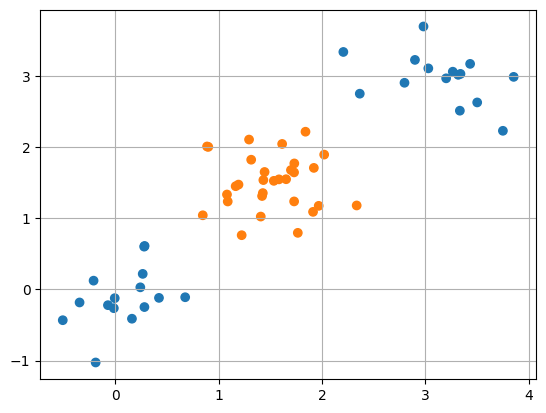

In [3]:
np.random.seed(11)
N = 30
noise_std = 1.5e-1

xs = np.vstack([
    np.random.multivariate_normal([0, 0], [[noise_std, 0], [0, noise_std]], size=(N // 2,)),
    np.random.multivariate_normal([1.5, 1.5], [[noise_std, 0], [0, noise_std]], size=(N,)),
    np.random.multivariate_normal([3, 3], [[noise_std, 0], [0, noise_std]], size=(N // 2,)),
])

ys = np.hstack([
    np.zeros(N // 2),
    np.ones(N),
    np.zeros(N // 2),
])

colors = [cmap[int(y)] for y in ys]

plt.scatter(xs[:, 0], xs[:, 1], c=colors)#, edgecolor="black")
plt.grid()

In [4]:
def r01():
    return np.random.uniform(0, 1)

In [5]:
N_NEURONS = 15

x0, x1 = Node(0.0), Node(0.0)
one = Node(1.0) # todo: int-to-node
y = Node(0.0)
eps = Node(1e-10)

ws = [
    [(Node(r01()), Node(r01())) for _ in range(N_NEURONS)],
    [(Node(r01()),) for _ in range(N_NEURONS)],
]
bs = [
    [Node(r01()) for _ in range(N_NEURONS)],
    [Node(r01()) for _ in range(N_NEURONS)],
]

out = []
for i in range(N_NEURONS):
    # layer x neurons x input
    out.append(relu(ws[0][i][0] * x0 + ws[0][i][1] * x1 + bs[0][i]))


out_sum = out[0]
for i in range(1, N_NEURONS):
    # layer x neurons x input
    out_sum += ws[1][i][0] * out[i] + bs[1][i]
    
out_sigmoid = sigmoid(out_sum)

# log-loss
loss = y * log(out_sigmoid + eps) + (one - y) * log(one - out_sigmoid + eps)

In [6]:
loss.forward()
loss.backward()
loss.val

-11.75767392772005

In [7]:
mu = 3e-2
N_iter = 1000
losses = []

for iter in range(N_iter):
    loss.zerograd()

    for i in range(1, xs.shape[0]):
        x0.val, x1.val = xs[i]
        y.val = ys[i]

        loss.forward()
        loss.backward()

        # print(out_sigmoid.val, loss.val)

    for w in ws:
        for neuron in w:
            for a in neuron:
                # plus because negative log-loss
                a.val += mu * a.grad / N

    for b in bs:
        for a in b:
            a.val += mu * a.grad / N

    losses.append(-loss.val)
    
    if iter % 10 == 0:
        print(f"iter {iter}, loss: {-loss.val:.6f}")
   

iter 0, loss: 23.025851
iter 10, loss: 23.025700
iter 20, loss: 22.951661
iter 30, loss: 0.451376
iter 40, loss: 0.544472
iter 50, loss: 0.588269
iter 60, loss: 0.610384
iter 70, loss: 0.619481
iter 80, loss: 0.621817
iter 90, loss: 0.621508
iter 100, loss: 0.620168
iter 110, loss: 0.618308
iter 120, loss: 0.615811
iter 130, loss: 0.613294
iter 140, loss: 0.610994
iter 150, loss: 0.608666
iter 160, loss: 0.606397
iter 170, loss: 0.603892
iter 180, loss: 0.601172
iter 190, loss: 0.598968
iter 200, loss: 0.596324
iter 210, loss: 0.593370
iter 220, loss: 0.590035
iter 230, loss: 0.586530
iter 240, loss: 0.582866
iter 250, loss: 0.579046
iter 260, loss: 0.575302
iter 270, loss: 0.571506
iter 280, loss: 0.567377
iter 290, loss: 0.562849
iter 300, loss: 0.557743
iter 310, loss: 0.552199
iter 320, loss: 0.546304
iter 330, loss: 0.539574
iter 340, loss: 0.532511
iter 350, loss: 0.525296
iter 360, loss: 0.517807
iter 370, loss: 0.509986
iter 380, loss: 0.502649
iter 390, loss: 0.493097
iter 400

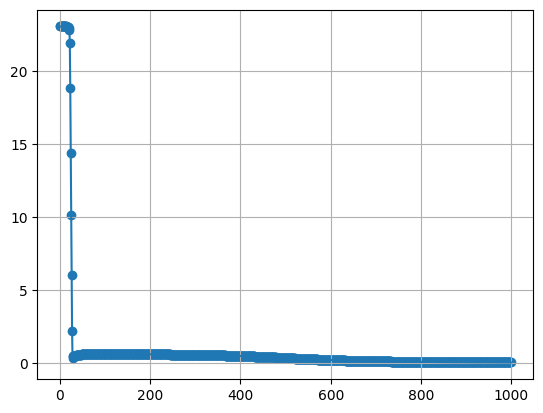

In [8]:
plt.scatter(range(N_iter), losses)
plt.plot(range(N_iter), losses)
plt.grid()

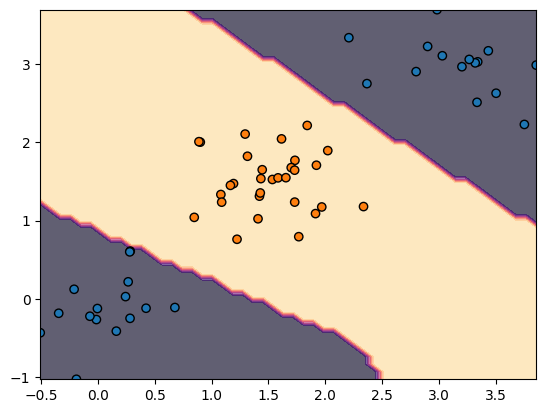

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap


feature_1, feature_2 = np.meshgrid(
    np.linspace(xs[:, 0].min(), xs[:, 0].max()),
    np.linspace(xs[:, 1].min(), xs[:, 1].max())
)
grid = np.vstack([feature_1.ravel(), feature_2.ravel()]).T

# y_pred generation
y_pred = []
for p in grid:
    x0.val, x1.val = p
    out_sigmoid.forward()
    y_pred.append(1 if out_sigmoid.val > 0.5 else 0)

y_pred = np.reshape(y_pred, feature_1.shape)

display = DecisionBoundaryDisplay(
    xx0=feature_1, xx1=feature_2, response=y_pred,
)
display.plot(
    # cmap=ListedColormap(cmap),
    cmap='magma',
    alpha=0.65,
    # plot_method='pcolormesh'
)
display.ax_.scatter(
    xs[:, 0], xs[:, 1], c=colors, edgecolor="black"
)
plt.show()

/home/tdinev/miniconda3/envs/py312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


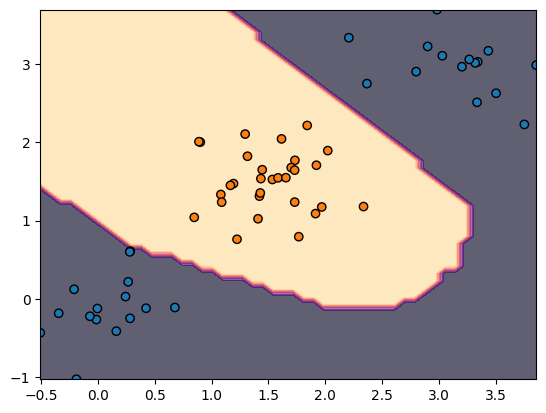

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap


feature_1, feature_2 = np.meshgrid(
    np.linspace(xs[:, 0].min(), xs[:, 0].max()),
    np.linspace(xs[:, 1].min(), xs[:, 1].max())
)
grid = np.vstack([feature_1.ravel(), feature_2.ravel()]).T
tree = MLPClassifier(hidden_layer_sizes=(15,), max_iter=1000, activation='relu').fit(xs, ys)
y_pred = np.reshape(tree.predict(grid), feature_1.shape)

display = DecisionBoundaryDisplay(
    xx0=feature_1, xx1=feature_2, response=y_pred,
)
display.plot(
    # cmap=ListedColormap(cmap),
    cmap='magma',
    alpha=0.65,
    # plot_method='pcolormesh'
)
display.ax_.scatter(
    xs[:, 0], xs[:, 1], c=colors, edgecolor="black"
)
plt.show()